
### **Sign Language Recognition - Deep Learning**


Libraries:

In [19]:


import cv2
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator 
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.optimizers import Adam, SGD
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping
import numpy as np
import matplotlib.pyplot as plt

Implementation:

In [24]:
def segmentation(frame, threshold=40):

    global background

    diff = cv2.absdiff(background.astype("uint8"), frame)

    _, processed_frame = cv2.threshold(
        diff,
        threshold,
        255,
        cv2.THRESH_BINARY
    )
    
    contours, _ = cv2.findContours(processed_frame, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    if len(contours) == 0:
        return None
    else :
        contours = max(contours, key=cv2.contourArea)

    return (processed_frame, contours)

### Generate Dataset

In [34]:
# =========================
# Camera Initialization
# =========================
cam = cv2.VideoCapture(0, cv2.CAP_V4L2)

# =========================
# ROI (Region of Interest)
# =========================
TOP = 50
BOTTOM = 300
RIGHT = 50
LEFT = 250

# =========================
# Global Variables
# =========================
background = None
count = 0
digit = 0
sample_num = 0


# =========================
# Main Loop
# =========================
while True:

    value, frame = cam.read()

    # Copy frame and flip (mirror effect)
    frame_copy = frame.copy()
    frame_copy = cv2.flip(frame_copy, 1)

    # ROI extraction
    roi = frame_copy[TOP:BOTTOM, RIGHT:LEFT]

    # Preprocessing
    roi_gray = cv2.cvtColor(roi, cv2.COLOR_BGR2GRAY)
    roi_gray = cv2.GaussianBlur(roi_gray, (7, 7), 0)

    # Initialize background
    if background is None:
        background = roi_gray.copy().astype("float")

    # Draw ROI rectangle
    cv2.rectangle(frame_copy, (RIGHT, TOP), (LEFT, BOTTOM), (0, 255, 0), 2)

    

    # Background learning (first 30 frames)
    if count < 30:
        cv2.accumulateWeighted(roi_gray, background, 0.5)
        cv2.putText(frame_copy, "Loading ...", (280, 280), cv2.FONT_HERSHEY_SIMPLEX, 1.5, (255, 255, 255), 2)


    # Hand segmentation
    collection = segmentation(roi_gray)

    if collection is not None:
        roi_processed, contours = collection 
        cv2.drawContours(
                        frame_copy,
                        [contours+(RIGHT, TOP)], # this is for alignment of contours with original frame
                        -1, # draw all contours
                        (0,0,255), 
                        2 
                                    ) 
        cv2.imshow("Processed", roi_processed)
        if k == ord(" "):
            cv2.putText(frame_copy, str(sample_num)+ "Gesture ("+ str(digit)+")", (70, 45), cv2.FONT_HERSHEY_SIMPLEX, 1, (255, 255, 255), 2)
            cv2.imwrite("gesture/train/" + str(digit) + "/" + str(digit) +"-" + str(sample_num) + ".jpg", roi_processed)
            sample_num += 1

    # Show camera
    cv2.putText(frame_copy, "Gesture ("+ str(digit)+")", (60, 350), cv2.FONT_HERSHEY_SIMPLEX, 1, (255, 255, 255), 2)
    cv2.imshow("Camera", frame_copy)
    count += 1

    # Exit with ESC
    k = cv2.waitKey(1)
    if k == 27:
        break
    
    elif k == 13: # Enter key to save the image
        
        digit = (digit + 1) % 11 
        sample_num = 0
        
        

# =========================
# Release Resources
# =========================
cam.release()
cv2.destroyAllWindows()

In [4]:
train_data_path = "gesture/train"
test_data_path = "gesture/test"

train_data_batches = ImageDataGenerator(preprocessing_function=tf.keras.applications.vgg16.preprocess_input).flow_from_directory(train_data_path,
                                                                                                                                 target_size=(64, 64),
                                                                                                                                 class_mode='categorical',
                                                                                                                                 batch_size=10,
                                                                                                                                 shuffle=True)

test_data_batches = ImageDataGenerator(preprocessing_function=tf.keras.applications.vgg16.preprocess_input).flow_from_directory(test_data_path,
                                                                                                                                 target_size=(64, 64),
                                                                                                                                 class_mode='categorical',
                                                                                                                                 batch_size=10,
                                                                                                                                 shuffle=True)

images_train, labels_train = next(train_data_batches)
print("Train Batch shape:", images_train.shape)
print("Train Labels shape:", labels_train.shape)

images_test, labels_test = next(test_data_batches)
print("Test Batch shape:", images_test.shape)
print("Test Labels shape:", labels_test.shape)

Found 3799 images belonging to 11 classes.
Found 462 images belonging to 11 classes.
Train Batch shape: (10, 64, 64, 3)
Train Labels shape: (10, 11)
Test Batch shape: (10, 64, 64, 3)
Test Labels shape: (10, 11)


In [5]:
def display(images):
    fig, axex = plt.subplots(1, 10, figsize=(30, 20))
    for image, ax in zip(images, axex):
        image = np.clip(image, 0, 1)
        ax.imshow(image)
        ax.axis("off")
    plt.tight_layout()
    plt.show()

In [6]:
print(train_data_batches.class_indices)

{'00': 0, '01': 1, '02': 2, '03': 3, '04': 4, '05': 5, '06': 6, '07': 7, '08': 8, '09': 9, '10': 10}


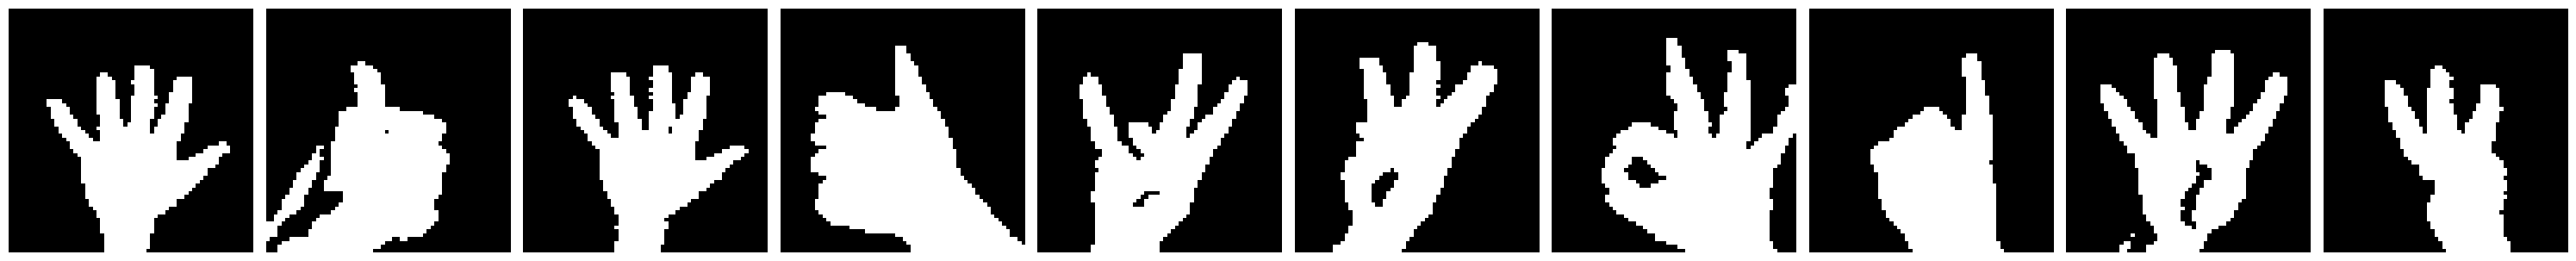

five
ten
five
ten
seven
six
nine
one
four
six


In [7]:
words = {0: "zero", 1: "one", 2: "two", 3: "three", 4: "four", 5: "five", 6: "six", 7: "seven", 8: "eight", 9: "nine", 10: "ten"}



display(images_train)


def digits(labels):
    for label in labels:
        print(words[np.argmax(label)])
    
digits(labels_train)

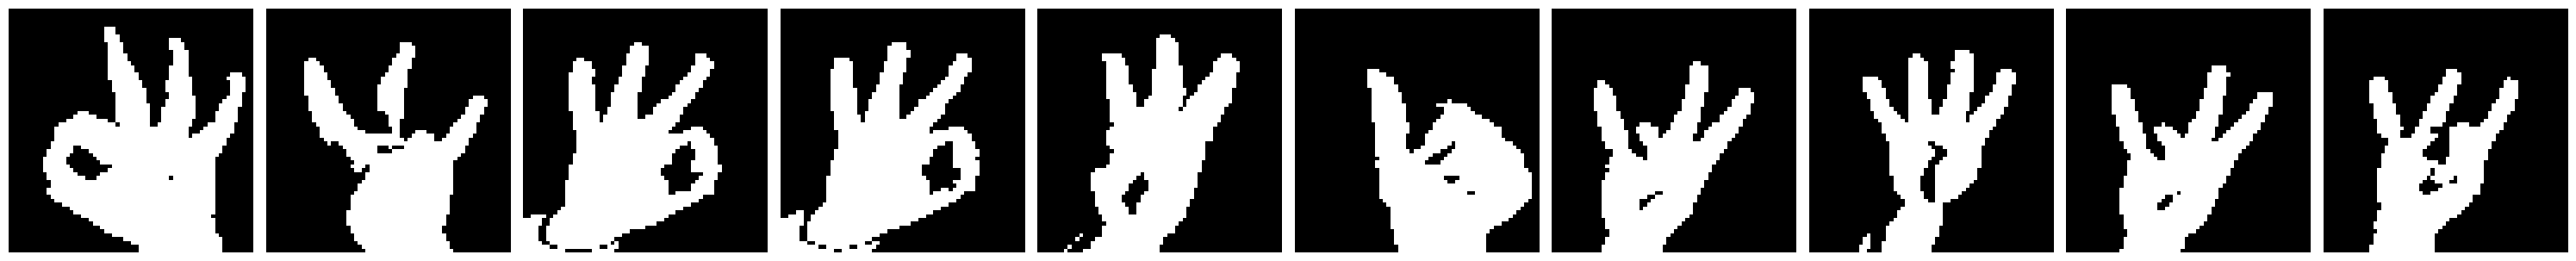

array([[0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0.],
       [0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0.],
       [0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1.],
       [0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0.],
       [0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0.]], dtype=float32)

In [6]:
display(images_test)
labels_test

### Create Cnn Model:

In [8]:
# CNN: Convolutional Neural Network

def createModel():
    model = Sequential()
    
    model.add(Conv2D(32, (3, 3), activation='relu', input_shape=(64, 64, 3)))
    model.add(MaxPooling2D(pool_size=(2, 2), strides=2))
    
    model.add(Conv2D(64, (3, 3), activation='relu', padding='same'))
    model.add(MaxPooling2D(pool_size=(2, 2), strides=2))
    
    model.add(Conv2D(128, (3, 3), activation='relu', padding='valid')) 
    model.add(MaxPooling2D(pool_size=(2, 2), strides=2))
    
    model.add(Flatten())
    
    model.add(Dense(64, activation='relu'))
    model.add(Dense(128, activation='relu')) 
    model.add(Dropout(0.2))
    
    model.add(Dense(128, activation='relu'))
    
    model.add(Dense(11, activation='softmax'))
    
    return model
 
model = createModel()
model.summary()

/home/sa7oom/.local/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
W0000 00:00:1773581116.583034 1592840 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 31, 31, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 15, 15, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 13, 13, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       294,976 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 11)             │         1,419 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 414,475 (1.58 MB)

 Trainable params: 414,475 (1.58 MB)

 Non-trainable params: 0 (0.00 B)

### Training Cnn Model:

In [9]:

model.compile(optimizer=Adam(learning_rate=0.0001), loss='categorical_crossentropy', metrics=['accuracy'])

reduce = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=1, min_lr= 0.0005)
early_stop = EarlyStopping(monitor='val_loss', min_delta=0, patience=1, mode='auto', verbose=1)

In [10]:
model.fit(train_data_batches, epochs=10, callbacks=[reduce, early_stop], validation_data=test_data_batches)

Epoch 1/10


I0000 00:00:1773581151.398351 1592840 generator_dataset_op.cc:213] Memory patch applied: M_TRIM_THRESHOLD=128 kb was set.


380/380 ━━━━━━━━━━━━━━━━━━━━ 9s 21ms/step - accuracy: 0.4688 - loss: 2.0490 - val_accuracy: 0.9589 - val_loss: 0.2078 - learning_rate: 1.0000e-04
Epoch 2/10
380/380 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - accuracy: 0.8971 - loss: 0.3114 - val_accuracy: 0.9913 - val_loss: 0.0227 - learning_rate: 1.0000e-04
Epoch 3/10
380/380 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.9703 - loss: 0.0888 - val_accuracy: 0.9935 - val_loss: 0.0253 - learning_rate: 1.0000e-04
Epoch 3: early stopping


### Testing

In [12]:
score = model.evaluate(images_test, labels_test, verbose=0)
score

[0.017045944929122925, 1.0]

In [13]:
model.metrics_names

['loss', 'compile_metrics']

In [14]:
print(f"{model.metrics_names[0]}: {score[0]}, {model.metrics_names[1]}: {score[1]*100}")

loss: 0.017045944929122925, compile_metrics: 100.0


### Model Save:

In [15]:
model.save("sign_language_model.h5")

### usning the model in prediction:

In [16]:
new_model = tf.keras.models.load_model("sign_language_model.h5")
new_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 31, 31, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 15, 15, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 13, 13, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       294,976 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 11)             │         1,419 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 414,477 (1.58 MB)

 Trainable params: 414,475 (1.58 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

In [18]:
# Camera Initialization
cam = cv2.VideoCapture(0, cv2.CAP_V4L2)


# ROI (Region of Interest) 
TOP = 50
BOTTOM = 300
RIGHT = 50
LEFT = 250


# Global Variables
background = None
count = 0
digit = 0
sample_num = 0
new_model = tf.keras.models.load_model("sign_language_model.h5")



# Main Loop
while True:

    value, frame = cam.read()

    # Copy frame and flip (mirror effect)
    frame_copy = frame.copy()
    frame_copy = cv2.flip(frame_copy, 1)

    # ROI extraction
    roi = frame_copy[TOP:BOTTOM, RIGHT:LEFT]

    # Preprocessing
    roi_gray = cv2.cvtColor(roi, cv2.COLOR_BGR2GRAY)
    roi_gray = cv2.GaussianBlur(roi_gray, (7, 7), 0)

    # Initialize background
    if background is None:
        background = roi_gray.copy().astype("float")

    # Draw ROI rectangle
    cv2.rectangle(frame_copy, (RIGHT, TOP), (LEFT, BOTTOM), (0, 255, 0), 2)

    

    # Background learning (first 30 frames)
    if count < 30:
        cv2.accumulateWeighted(roi_gray, background, 0.5)
        cv2.putText(frame_copy, "Loading ...", (280, 280), cv2.FONT_HERSHEY_SIMPLEX, 1.5, (255, 255, 255), 2)


    # Hand segmentation
    collection = segmentation(roi_gray)

    if collection is not None:
        roi_processed, contours = collection 
        cv2.drawContours(
                        frame_copy,
                        [contours+(RIGHT, TOP)], # this is for alignment of contours with original frame
                        -1, # draw all contours
                        (0,0,255), 
                        2 
                                    ) 
        
        
        roi_processed = cv2.resize(roi_processed, (64, 64))
        roi_processed = cv2.cvtColor(roi_processed, cv2.COLOR_GRAY2RGB)
        frame = np.reshape(roi_processed, (1, roi_processed.shape[0], roi_processed.shape[1], 3))
        value = new_model.predict(frame)
        label = words[np.argmax(value)]
        cv2.putText(frame_copy, str(label), (370, 145), cv2.FONT_HERSHEY_SIMPLEX, 2, (255, 255, 255), 3)
        
        
        
        
        
        
        if k == ord(" "):
            cv2.putText(frame_copy, str(sample_num)+ "Gesture ("+ str(digit)+")", (70, 45), cv2.FONT_HERSHEY_SIMPLEX, 1, (255, 255, 255), 2)
            cv2.imwrite("gesture/train/" + str(digit) + "/" + str(digit) +"-" + str(sample_num) + ".jpg", roi_processed)
            sample_num += 1

        cv2.imshow("Processed", roi_processed)
    # Show camera
    cv2.putText(frame_copy, "Gesture ("+ str(digit)+")", (60, 350), cv2.FONT_HERSHEY_SIMPLEX, 1, (255, 255, 255), 2)
    cv2.imshow("Camera", frame_copy)
    count += 1

    # Exit with ESC
    k = cv2.waitKey(1)
    if k == 27:
        break
    
    elif k == 13: # Enter key to save the image
        
        digit = (digit + 1) % 11 
        sample_num = 0
        
        


# Release Resources
cam.release()
cv2.destroyAllWindows()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━